In [6]:
import seaborn as sns
import pandas as pd
from matplotlib import pyplot as plt
from boats.lib.common import *
from boats.lib.boat import Boat

In [7]:
boatname = 'Petsamo'

sails = ['Nr.1', 'Nr.2', 'Nr.3', 'Stormjib', 'Mainsail', 'Genaker', 'Mizzen', 'Mizzen staysail']
points_of_sail={
    'close haul': list(range(0,37)),
    'close reach': list(range(36,73)),
    'beam': list(range(72,109)),
    'broad reach': list(range(108,145)),
    'run': list(range(144,181))
}
yesmark = 'x'
nomark = '-'

In [12]:
df=Boat(boatname).get_logged_data()
df.dropna(inplace=True)
df['heel']=df['heel'].apply(lambda x: int(abs(x)))
df['twa']=df['twa'].apply(lambda x: abs(x))
df=df[df['spd']!=0]
df['spd / tws']=round(df['spd']/df['tws'],2)
df.reset_index(inplace=True, drop=True)
df.head()

,tws,spd,twd,twa,heel,lat,lon,sails,spd / tws
0,14.1,5.5,20,45,27,0.61673,129.61302,"[Mainsail, Mizzen, Nr.2]",0.39
1,14.1,5.5,20,45,27,0.61838,129.61253,"[Mainsail, Mizzen, Nr.2]",0.39
2,14.1,5.5,20,45,27,0.61838,129.61253,"[Mainsail, Mizzen, Nr.2]",0.39
3,14.1,5.5,20,45,27,0.62002,129.61203,"[Mainsail, Mizzen, Nr.2]",0.39
4,14.1,5.5,20,45,27,0.62002,129.61203,"[Mainsail, Mizzen, Nr.2]",0.39


In [13]:
len(df)

59

#### Expand sail data:

In [14]:
for i in range(len(df.index)):
    for sail in sails:
        if sail in df.iloc[i]['sails']:
            mark = yesmark
        else:
            mark = nomark
        df.at[i, sail] = mark
        
df.drop(['sails'], axis=1, inplace=True)
df.head()    

,tws,spd,twd,twa,heel,lat,lon,spd / tws,Nr.1,Nr.2,Nr.3,Stormjib,Mainsail,Genaker,Mizzen,Mizzen staysail
0,14.1,5.5,20,45,27,0.61673,129.61302,0.39,-,x,-,-,x,-,x,-
1,14.1,5.5,20,45,27,0.61838,129.61253,0.39,-,x,-,-,x,-,x,-
2,14.1,5.5,20,45,27,0.61838,129.61253,0.39,-,x,-,-,x,-,x,-
3,14.1,5.5,20,45,27,0.62002,129.61203,0.39,-,x,-,-,x,-,x,-
4,14.1,5.5,20,45,27,0.62002,129.61203,0.39,-,x,-,-,x,-,x,-


In [15]:
df['pos'] = [name for i in df.index for name in points_of_sail if df.iloc[i]['twa'] in points_of_sail[name]]
df

,tws,spd,twd,twa,heel,lat,lon,spd / tws,Nr.1,Nr.2,Nr.3,Stormjib,Mainsail,Genaker,Mizzen,Mizzen staysail,pos
0,14.1,5.5,20,45,27,0.61673,129.61302,0.39,-,x,-,-,x,-,x,-,close reach
1,14.1,5.5,20,45,27,0.61838,129.61253,0.39,-,x,-,-,x,-,x,-,close reach
2,14.1,5.5,20,45,27,0.61838,129.61253,0.39,-,x,-,-,x,-,x,-,close reach
3,14.1,5.5,20,45,27,0.62002,129.61203,0.39,-,x,-,-,x,-,x,-,close reach
4,14.1,5.5,20,45,27,0.62002,129.61203,0.39,-,x,-,-,x,-,x,-,close reach
5,14.1,5.5,20,45,27,0.62167,129.61154,0.39,-,x,-,-,x,-,x,-,close reach
6,14.0,5.5,22,45,27,0.66555,129.59935,0.39,-,x,-,-,x,-,x,-,close reach
7,13.1,5.5,26,45,26,1.05876,129.68960,0.42,-,x,-,-,x,-,x,-,close reach
8,12.9,5.4,26,45,26,1.07555,129.68542,0.42,-,x,-,-,x,-,x,-,close reach
9,12.7,5.4,26,45,26,1.10755,129.67753,0.43,-,x,-,-,x,-,x,-,close reach


[Text(0.5, 1.0, 'Speed by point of sale')]

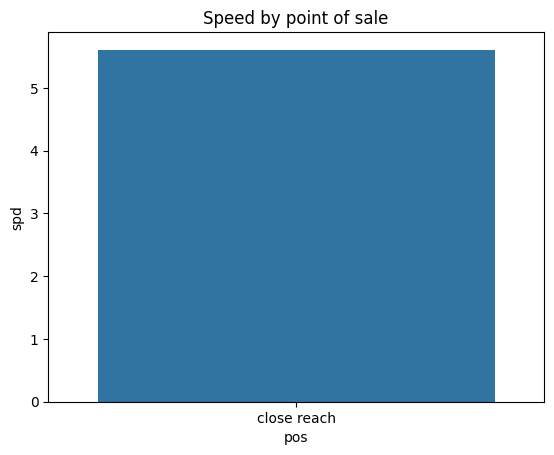

In [16]:
df_plot=df[['pos', 'spd']].groupby('pos').mean().sort_values('pos')
sns.barplot(data=df_plot, x=df_plot.index, y='spd').set(title='Speed by point of sale')

[Text(0.5, 1.0, 'Points of sail frequency')]

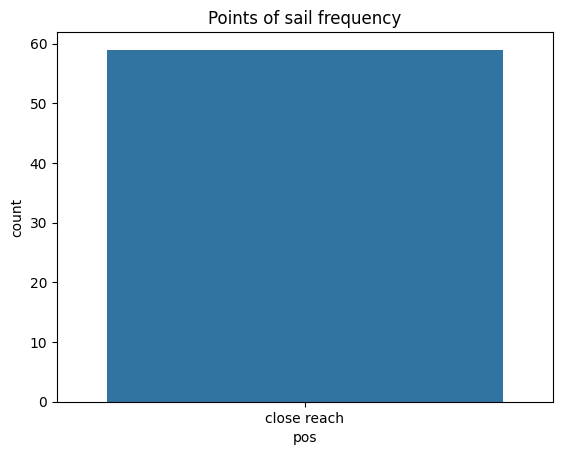

In [19]:
sns.countplot(data=df.sort_values('pos'), x='pos').set(title='Points of sail frequency')

In [28]:
sns.lineplot(data=df[['heel', 'spd']].groupby('heel').mean(), x=df_plot.index, y='spd').set(title='Speed by heel')

ValueError: Length of Index vectors must match length of `data` when both are used, but `data` has length 14 and the vector passed to `x` has length 1.

[Text(0.5, 1.0, 'spd to tws')]

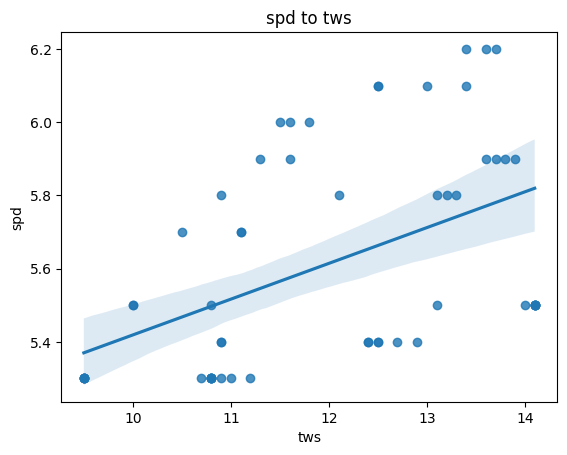

In [21]:
sns.regplot(data=df, x='tws', y='spd').set(title='spd to tws')

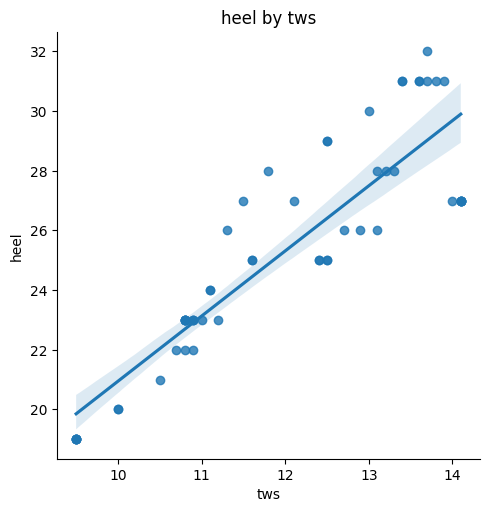

In [22]:
sns.lmplot(data=df, x='tws', y='heel').set(title='heel by tws')

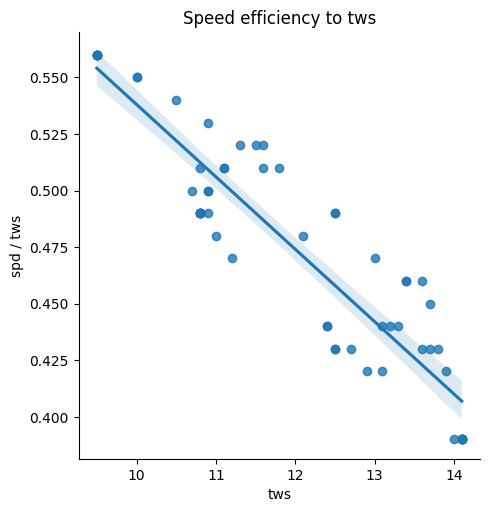

In [23]:
sns.lmplot(data=df, x='tws', y='spd / tws').set(title='Speed efficiency to tws')

In [24]:
df_pos=df.sort_values('twa')[['pos'] + sails].reset_index(drop=True)
df_pos

,pos,Nr.1,Nr.2,Nr.3,Stormjib,Mainsail,Genaker,Mizzen,Mizzen staysail
0,close reach,-,x,-,-,x,-,x,-
1,close reach,-,x,-,-,x,-,x,-
2,close reach,-,x,-,-,x,-,x,-
3,close reach,-,x,-,-,x,-,x,-
4,close reach,-,x,-,-,x,-,x,-
5,close reach,-,x,-,-,x,-,x,-
6,close reach,-,x,-,-,x,-,x,-
7,close reach,-,x,-,-,x,-,x,-
8,close reach,-,x,-,-,x,-,x,-
9,close reach,-,x,-,-,x,-,x,-


In [25]:
df_pos=df_pos.replace(yesmark, 1)
df_pos=df_pos.replace(nomark, 0)
df_pos

,pos,Nr.1,Nr.2,Nr.3,Stormjib,Mainsail,Genaker,Mizzen,Mizzen staysail
0,close reach,0,1,0,0,1,0,1,0
1,close reach,0,1,0,0,1,0,1,0
2,close reach,0,1,0,0,1,0,1,0
3,close reach,0,1,0,0,1,0,1,0
4,close reach,0,1,0,0,1,0,1,0
5,close reach,0,1,0,0,1,0,1,0
6,close reach,0,1,0,0,1,0,1,0
7,close reach,0,1,0,0,1,0,1,0
8,close reach,0,1,0,0,1,0,1,0
9,close reach,0,1,0,0,1,0,1,0


In [26]:
df_plot=df_pos.groupby('pos').sum()
df_plot

,Nr.1,Nr.2,Nr.3,Stormjib,Mainsail,Genaker,Mizzen,Mizzen staysail
pos,,,,,,,,
close reach,17,42,0,0,59,0,59,0


[Text(0.5, 1.0, 'Sail types usage by point of sail')]

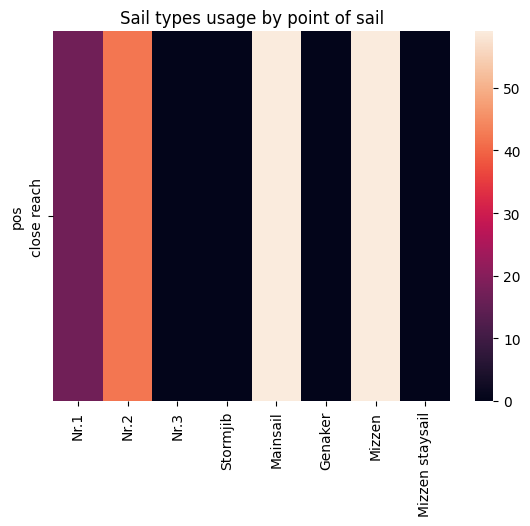

In [27]:
sns.heatmap(df_plot).set(title='Sail types usage by point of sail')

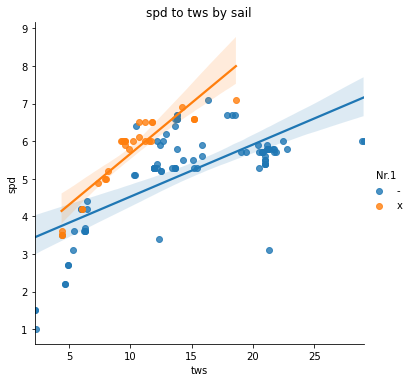

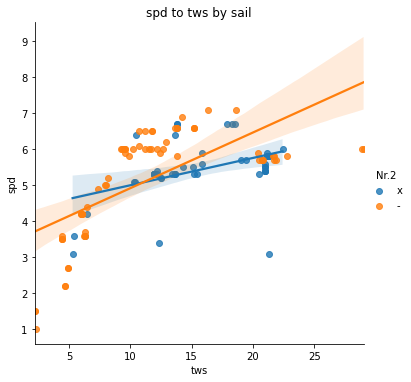

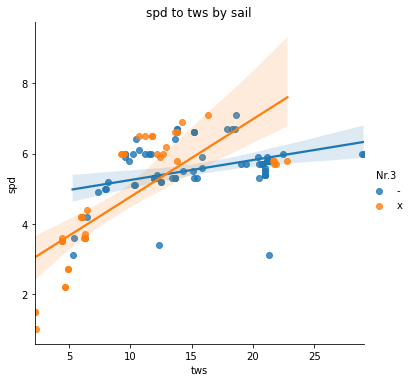

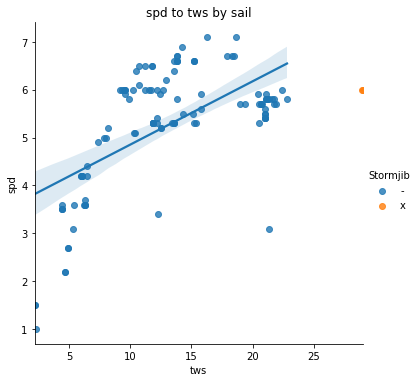

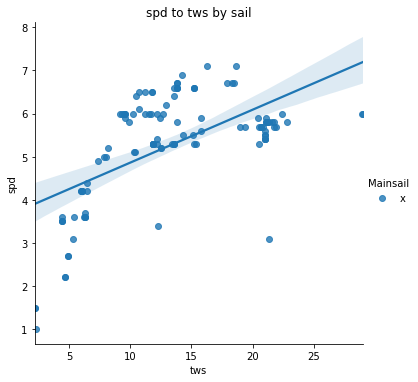

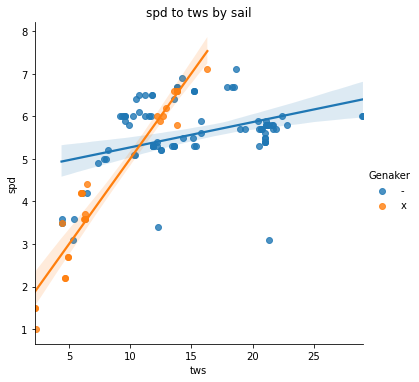

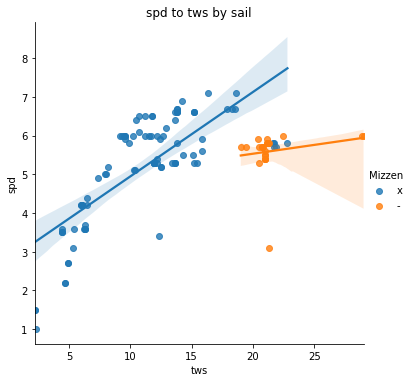

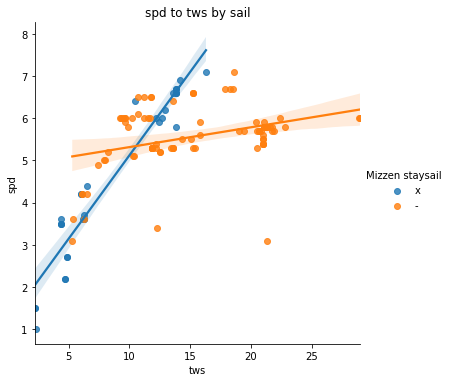

In [45]:
for sail in sails:
    sns.lmplot(data=df, x='tws', y='spd', hue=sail).set(title='spd to tws by sail')